# Phase 4 — Bet Tracing

**CS-GY 6513 Big Data, Spring 2026**  
Rodrigo Arguello (ra2646) | Shwetanshu Raj (sr8250)

---

## Overview

Phase 3 identified **569 spike events** — 5-minute windows where the implied probability moved anomalously relative to its recent baseline. This phase answers: *who was trading before those spikes?*

### Pipeline

1. Load `polymarket.spike_events` and `polymarket.ticks` from BigQuery
2. For each spike, define a **24-hour look-back window**: `[spike_timestamp − 24h, spike_timestamp)`
3. **Temporal join**: find all ticks in the look-back window that match the spike's market and direction
   - **Takers** on the spike side (e.g. bought YES before a YES spike)
   - **Makers** on the opposite side (e.g. sold NO before a YES spike — also a directional bet)
4. Aggregate per `(wallet, spike)`: total USD traded, fill count, average price, earliest trade time
5. Compute `hours_before_spike` — how early did the wallet start accumulating?
6. Filter to wallets above a minimum USD threshold
7. Write `polymarket.suspect_wallets` to BigQuery

### Why takers AND makers?

In a binary prediction market, a YES spike means the event became more likely. Two types of wallet benefited:
- **Taker on YES side** — directly bought YES tokens before the spike (clear directional bet)
- **Maker on NO side** — provided NO tokens to buyers, collecting cash; when NO → 0 they keep that cash (equivalent directional profit)

Both are suspicious if they traded in the 24h window before a large price spike.

### Execution Modes

| Mode | Value |
|---|---|
| Local (development) | `local[*]` |
| Standalone cluster | `spark://localhost:7077` |

---

## 1. Setup

### 1.1 Imports and Constants

In [1]:
%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F

# ── GCP config ────────────────────────────────────────────────────────────────
PROJECT = "sr8250-cs6513-polymarket"
DATASET = "polymarket"
BUCKET = "cs6513-polymarket"

ROOT = Path.cwd().parent
JAR = str(ROOT / "jars" / "spark-bigquery-with-dependencies_2.12-0.36.1.jar")

# ── Spark master — change to spark://localhost:7077 for standalone cluster ────
SPARK_MASTER = "local[*]"

# ── Tracing parameters ────────────────────────────────────────────────────────
LOOKBACK_HOURS = 24      # how many hours before a spike to search for pre-event trades
MIN_WALLET_USD = 100.0   # wallets below this total USD in the look-back window are excluded

# ── Chart output folder ───────────────────────────────────────────────────────
CHART_DIR = Path("trace_charts")
CHART_DIR.mkdir(exist_ok=True)

### 1.2 Spark Session

In [2]:
spark = (
    SparkSession.builder
    .appName("polymarket-bet-tracing")
    .master(SPARK_MASTER)
    .config("spark.jars", JAR)
    .config("spark.driver.host", "localhost")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

print(f"Spark version : {spark.version}")
print(f"Master        : {spark.sparkContext.master}")
print(f"App name      : {spark.sparkContext.appName}")

26/05/03 08:17:18 WARN Utils: Your hostname, Shwetanshus-MacBook-Air-2.local resolves to a loopback address: 127.0.0.1; using 192.168.1.166 instead (on interface en0)
26/05/03 08:17:18 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


26/05/03 08:17:19 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark version : 3.5.1
Master        : local[*]
App name      : polymarket-bet-tracing


### 1.3 Helper: Write DataFrame to BigQuery

In [3]:
def write_bq(df, table):
    """
    Writes a Spark DataFrame to a BigQuery table, overwriting any existing data

    Args:
        df: The Spark DataFrame to write
        table: The BigQuery table name within the configured dataset
    """
    # 2 partitions = 2 concurrent write streams; more overwhelms the Storage Write API
    (
        df.repartition(2)
        .write
        .format("bigquery")
        .option("table", f"{PROJECT}.{DATASET}.{table}")
        .option("writeMethod", "direct")
        .mode("overwrite")
        .save()
    )

---

## 2. Load Data from BigQuery

### 2.1 Load Spike Events

In [4]:
t0 = time.time()

spikes_raw = (
    spark.read
    .format("bigquery")
    .option("table", f"{PROJECT}.{DATASET}.spike_events")
    .load()
)

spike_count = spikes_raw.count()
elapsed = time.time() - t0

print(f"Spike events loaded : {spike_count}")
print(f"Time                : {elapsed:.1f}s")
spikes_raw.printSchema()

Spike events loaded : 569
Time                : 3.5s
root
 |-- market_slug: string (nullable = true)
 |-- side: string (nullable = true)
 |-- window_start: timestamp (nullable = true)
 |-- window_end: timestamp (nullable = true)
 |-- vwap: double (nullable = true)
 |-- price_before: double (nullable = true)
 |-- price_after: double (nullable = true)
 |-- rolling_mean: double (nullable = true)
 |-- rolling_std: double (nullable = true)
 |-- z_score: double (nullable = true)
 |-- volume_usd: double (nullable = true)
 |-- trade_count: long (nullable = false)



> **What this output means:**
>
> We loaded the 569 spike events that Phase 3 wrote to BigQuery. Each row is one 5-minute window that had an anomalous price move (z-score > 3.0, volume ≥ $100). The schema shows:
> - `market_slug` + `side` + `window_start` — uniquely identifies which market, direction, and time window spiked
> - `z_score` — how many standard deviations above the rolling baseline the VWAP was
> - `price_before` / `vwap` — the price just before and during the spike
> - `volume_usd` — total dollars traded in that 5-minute window
>
> These 569 spike windows are the targets for bet tracing. For each one, we will look back 24 hours and find every wallet that was betting in the same direction.

### 2.2 Preview Spike Distribution per Market

In [5]:
spikes_raw.groupBy("market_slug", "side").agg(
    F.count("*").alias("spike_count"),
    F.round(F.max("z_score"), 2).alias("max_z"),
    F.round(F.avg("z_score"), 2).alias("avg_z"),
).orderBy("market_slug", "side").show(truncate=False)

+-------------------------+----+-----------+-----+-----+
|market_slug              |side|spike_count|max_z|avg_z|
+-------------------------+----+-----------+-----+-----+
|china-invades-taiwan-2026|no  |27         |8.14 |3.86 |
|china-invades-taiwan-2026|yes |12         |4.34 |3.7  |
|khamenei-out-feb28       |no  |35         |8.03 |3.91 |
|khamenei-out-feb28       |yes |28         |10.92|4.51 |
|maduro-out-jan31         |no  |15         |6.71 |4.16 |
|maduro-out-jan31         |yes |12         |33.3 |7.5  |
|us-forces-iran-mar31     |no  |101        |11.09|4.23 |
|us-forces-iran-mar31     |yes |126        |60.9 |4.88 |
|us-iran-ceasefire-jun30  |no  |15         |4.6  |3.53 |
|us-iran-ceasefire-jun30  |yes |21         |15.7 |5.16 |
|us-strikes-iran-feb28    |no  |96         |8.72 |4.02 |
|us-strikes-iran-feb28    |yes |81         |17.89|4.15 |
+-------------------------+----+-----------+-----+-----+



> **What this output means:**
>
> Spike counts broken down by market and side. This tells us how many look-back windows we will search per market. Markets with more spikes produce more suspects to evaluate — the goal of Phase 5 is to score which suspects appear repeatedly across multiple spikes.
>
> `max_z` shows the single most extreme price move in each market. The YES sides of resolved markets show the highest max z-scores because we know those events actually happened.

### 2.3 Load Ticks

In [6]:
t0 = time.time()

ticks = (
    spark.read
    .format("bigquery")
    .option("table", f"{PROJECT}.{DATASET}.ticks")
    .load()
    .select("market_slug", "side", "timestamp", "implied_price", "size_usd", "maker", "taker")
)

tick_count = ticks.count()
elapsed = time.time() - t0

print(f"Ticks loaded : {tick_count:,}")
print(f"Time         : {elapsed:.1f}s")

Ticks loaded : 329,373
Time         : 0.4s


> **What this output means:**
>
> The 329,373 individual trades are loaded. We select only the 7 columns we need for this phase — dropping `transaction_hash` which is not needed for wallet tracing. Each row represents one trade with: which market and side, when it happened, what price was paid, how many USD changed hands, and the wallet addresses of both the buyer (taker) and the liquidity provider (maker).

---

## 3. Prepare Look-Back Windows

Before joining, we add three derived columns to the spikes DataFrame:

| Column | Description |
|---|---|
| `spike_id` | Integer ID (row number ordered by market, side, time) |
| `lookback_start` | `window_start − 24 hours` — the earliest timestamp to search for pre-spike trades |
| `opposite_side` | The other side ("no" if spike was on "yes", and vice versa) — used to find makers on the correct side |

The `spike_id` lets us track which spike each suspect wallet was associated with across the full pipeline.

In [7]:
id_window = Window.orderBy("market_slug", "side", "window_start")

spikes_prep = (
    spikes_raw
    .withColumn("spike_id", F.row_number().over(id_window))
    .withColumn("lookback_start", F.col("window_start") - F.expr(f"INTERVAL {LOOKBACK_HOURS} hours"))
    .withColumn(
        "opposite_side",
        F.when(F.col("side") == "yes", F.lit("no")).otherwise(F.lit("yes")),
    )
)

print(f"Spikes prepared : {spikes_prep.count()} rows")
spikes_prep.select(
    "spike_id", "market_slug", "side", "window_start", "lookback_start", "opposite_side", "z_score"
).orderBy(F.desc("z_score")).show(5, truncate=False)

Spikes prepared : 569 rows


26/05/03 08:17:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:17:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:17:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+--------+-----------------------+----+-------------------+-------------------+-------------+------------------+
|spike_id|market_slug            |side|window_start       |lookback_start     |opposite_side|z_score           |
+--------+-----------------------+----+-------------------+-------------------+-------------+------------------+
|333     |us-forces-iran-mar31   |yes |2026-03-26 04:10:00|2026-03-25 04:10:00|no           |60.900681205132145|
|126     |maduro-out-jan31       |yes |2026-01-03 01:15:00|2026-01-02 01:15:00|no           |33.301595262159545|
|490     |us-strikes-iran-feb28  |yes |2026-01-22 21:40:00|2026-01-21 21:40:00|no           |17.888267368499847|
|334     |us-forces-iran-mar31   |yes |2026-03-27 09:50:00|2026-03-26 09:50:00|no           |15.815173247663873|
|380     |us-iran-ceasefire-jun30|yes |2026-03-23 07:10:00|2026-03-22 07:10:00|no           |15.696087381575888|
+--------+-----------------------+----+-------------------+-------------------+-------------+---

26/05/03 08:17:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:17:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


> **What this output means:**
>
> Each spike now has a unique integer `spike_id` and a computed `lookback_start` which is exactly 24 hours before the spike window. For example, if a spike fired at 2026-03-26 04:10, the look-back window is 2026-03-25 04:10 → 2026-03-26 04:10.
>
> The `opposite_side` column flips the side. We need this for the maker join: a maker appearing in a NO-side fill is actually selling NO contracts, which is a bet that YES will happen. If there's a YES spike, those makers also benefited and should be investigated.

---

## 4. Temporal Join — Find Pre-Spike Trades

We do two joins against the ticks table. Both use `F.broadcast(spikes_prep)` because the spikes table is tiny (569 rows) — broadcasting sends a copy to each Spark executor so it can be joined locally against its partition of ticks without any data shuffle.

### 4.1 Takers on the Correct Side

A taker on the YES side bought YES tokens. If YES price then spikes, they profit. We want every taker who was active in the 24h before a YES spike, on the same market.

In [8]:
t0 = time.time()

taker_matches = (
    ticks.alias("t")
    .join(
        F.broadcast(spikes_prep).alias("s"),
        (
            (F.col("t.market_slug") == F.col("s.market_slug")) &
            (F.col("t.side") == F.col("s.side")) &
            (F.col("t.timestamp") >= F.col("s.lookback_start")) &
            (F.col("t.timestamp") < F.col("s.window_start"))
        ),
    )
    .filter(F.col("t.taker").isNotNull())
    .select(
        F.col("s.spike_id"),
        F.col("s.market_slug"),
        F.col("s.side").alias("spike_side"),
        F.col("s.window_start").alias("spike_timestamp"),
        F.col("t.taker").alias("wallet_address"),
        F.lit("taker").alias("role"),
        F.col("t.size_usd"),
        F.col("t.implied_price"),
        F.col("t.timestamp").alias("trade_timestamp"),
    )
)

taker_count = taker_matches.count()
elapsed = time.time() - t0
print(f"Taker match rows : {taker_count:,}")
print(f"Time             : {elapsed:.1f}s")

Taker match rows : 720,622
Time             : 7.9s


> **What this output means:**
>
> Each row is one tick that falls within the 24-hour look-back window of a spike, where the taker was buying on the spike's direction. A single wallet may appear many times if it made multiple trades in the window — those will be aggregated in the next step.
>
> This is a one-to-many join: one spike can match many ticks, and one tick can match multiple spikes if its timestamp falls within several overlapping look-back windows (because spikes for the same market can occur on consecutive days).

### 4.2 Makers on the Correct Side

For a YES spike, the maker on a NO-side fill sold NO tokens. Since NO → 0 when YES resolves, they pocketed the sale price and owe nothing. This is economically equivalent to buying YES — they also had directional conviction that the event would happen.

In [9]:
t0 = time.time()

maker_matches = (
    ticks.alias("t")
    .join(
        F.broadcast(spikes_prep).alias("s"),
        (
            (F.col("t.market_slug") == F.col("s.market_slug")) &
            (F.col("t.side") == F.col("s.opposite_side")) &
            (F.col("t.timestamp") >= F.col("s.lookback_start")) &
            (F.col("t.timestamp") < F.col("s.window_start"))
        ),
    )
    .filter(F.col("t.maker").isNotNull())
    .select(
        F.col("s.spike_id"),
        F.col("s.market_slug"),
        F.col("s.side").alias("spike_side"),
        F.col("s.window_start").alias("spike_timestamp"),
        F.col("t.maker").alias("wallet_address"),
        F.lit("maker").alias("role"),
        F.col("t.size_usd"),
        F.col("t.implied_price"),
        F.col("t.timestamp").alias("trade_timestamp"),
    )
)

maker_count = maker_matches.count()
elapsed = time.time() - t0
print(f"Maker match rows : {maker_count:,}")
print(f"Time             : {elapsed:.1f}s")

Maker match rows : 711,314
Time             : 6.4s


> **What this output means:**
>
> These are the maker-side counterparts. A row here means: a maker was providing liquidity on the opposite side of the spike direction in the 24 hours before the spike. For a YES spike, they were in NO-side fills, selling NO tokens — a directional bet that YES would win.
>
> Makers typically show lower total counts than takers because market makers place limit orders that get filled gradually, while a taker may cross the spread in one aggressive buy. Both are worth investigating.

---

## 5. Aggregate by Wallet

Union both match sets and aggregate per `(wallet_address, role, spike_id)`. We compute:

| Field | Meaning |
|---|---|
| `total_usd` | Total dollars this wallet traded in the look-back window |
| `fill_count` | Number of individual trades |
| `avg_price` | Dollar-weighted average implied price they paid |
| `first_bet_timestamp` | Their earliest trade in the window |
| `hours_before_spike` | How early they started (spike_time − first_bet) in hours |

In [10]:
t0 = time.time()

all_matches = taker_matches.union(maker_matches)

suspects_raw = (
    all_matches
    .groupBy(
        "spike_id", "market_slug", "spike_side", "spike_timestamp",
        "wallet_address", "role",
    )
    .agg(
        F.round(F.sum("size_usd"), 4).alias("total_usd"),
        F.count("*").alias("fill_count"),
        F.round(
            F.sum(F.col("implied_price") * F.col("size_usd")) / F.sum("size_usd"), 4
        ).alias("avg_price"),
        F.min("trade_timestamp").alias("first_bet_timestamp"),
    )
    .withColumn(
        "hours_before_spike",
        F.round(
            (F.unix_timestamp("spike_timestamp") - F.unix_timestamp("first_bet_timestamp")) / 3600,
            2,
        ),
    )
)

raw_count = suspects_raw.count()
elapsed = time.time() - t0

print(f"Wallet-spike pairs (before filter) : {raw_count:,}")
print(f"Time                               : {elapsed:.1f}s")
suspects_raw.orderBy(F.desc("total_usd")).show(10, truncate=False)

26/05/03 08:17:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:17:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:17:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:17:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


26/05/03 08:17:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:17:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:17:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:17:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


Wallet-spike pairs (before filter) : 389,278
Time                               : 34.1s


26/05/03 08:18:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:18:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:18:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:18:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


26/05/03 08:18:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:18:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:18:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:18:18 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+--------+--------------------+----------+-------------------+------------------------------------------+-----+----------+----------+---------+-------------------+------------------+
|spike_id|market_slug         |spike_side|spike_timestamp    |wallet_address                            |role |total_usd |fill_count|avg_price|first_bet_timestamp|hours_before_spike|
+--------+--------------------+----------+-------------------+------------------------------------------+-----+----------+----------+---------+-------------------+------------------+
|102     |khamenei-out-feb28  |yes       |2026-02-28 20:35:00|0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e|taker|4451215.0 |7162      |0.7968   |2026-02-27 20:46:11|23.81             |
|101     |khamenei-out-feb28  |yes       |2026-02-28 14:35:00|0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e|taker|1458196.43|4666      |0.4757   |2026-02-27 14:37:59|23.95             |
|100     |khamenei-out-feb28  |yes       |2026-02-28 14:30:00|0x4bfb41d5b3570defd03c3

> **What this output means:**
>
> Each row is now one wallet's activity around one spike — fully aggregated. The top rows by `total_usd` show the wallets that traded the most money in the 24h before some spike.
>
> Key columns to read:
> - `total_usd` — the total dollars this wallet put in during the window (larger = more confident or more capital)
> - `avg_price` — the average price they paid. A low avg_price on a YES side means they bought when YES was cheap, *before* the spike. This is the most informative column for detecting insider timing.
> - `hours_before_spike` — how early their first trade was relative to the spike. Close to 24 means they started very early; close to 0 means they jumped in right before.
> - `fill_count` — number of individual fills. Many small fills vs a few large ones is a different trading style.

---

## 6. Filter to Significant Suspects

We apply two filters:
1. `total_usd >= MIN_WALLET_USD` ($100) — removes wallets with negligible exposure who are unlikely to be meaningfully informed
2. `hours_before_spike > 0` — ensures the wallet traded *before* the spike, not in the same window

In [11]:
suspects = (
    suspects_raw
    .filter(F.col("total_usd") >= MIN_WALLET_USD)
    .filter(F.col("hours_before_spike") > 0)
    .orderBy("market_slug", "spike_side", "spike_timestamp", F.desc("total_usd"))
)

suspect_count = suspects.count()
print(f"Suspect wallet-spike entries : {suspect_count:,}")
print(f"Min wallet threshold         : ${MIN_WALLET_USD:,.0f}")
print(f"Dropped (below threshold)    : {raw_count - suspect_count:,}")

# Count distinct wallets
distinct_wallets = suspects.select("wallet_address").distinct().count()
print(f"Distinct suspect wallets     : {distinct_wallets:,}")

26/05/03 08:19:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:19:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:19:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:19:16 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


26/05/03 08:19:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:19:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:19:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:19:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


Suspect wallet-spike entries : 128,096
Min wallet threshold         : $100
Dropped (below threshold)    : 261,182


26/05/03 08:20:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:20:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:20:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:20:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


26/05/03 08:20:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:20:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:20:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:20:09 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


Distinct suspect wallets     : 13,068


> **What this output means:**
>
> After filtering, we have the final set of suspect (wallet, spike) pairs. Each entry represents a wallet that:
> - Traded at least $100 in the correct direction
> - Did so *before* the spike (not during)
>
> `distinct_wallets` is the number of unique wallet addresses across all spikes and markets. A single wallet appearing as a suspect in multiple spikes is a strong signal — Phase 5 will compute a prescience score that rewards wallets that appear repeatedly.

### Suspects per Market and Side

In [12]:
suspects.groupBy("market_slug", "spike_side").agg(
    F.countDistinct("wallet_address").alias("unique_wallets"),
    F.count("*").alias("wallet_spike_pairs"),
    F.round(F.sum("total_usd"), 0).alias("total_usd_in_window"),
    F.round(F.avg("hours_before_spike"), 1).alias("avg_hours_before"),
).orderBy("market_slug", "spike_side").show(truncate=False)

26/05/03 08:20:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:20:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:20:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:20:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


26/05/03 08:20:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:20:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:20:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:20:50 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+-------------------------+----------+--------------+------------------+-------------------+----------------+
|market_slug              |spike_side|unique_wallets|wallet_spike_pairs|total_usd_in_window|avg_hours_before|
+-------------------------+----------+--------------+------------------+-------------------+----------------+
|china-invades-taiwan-2026|no        |241           |404               |862687.0           |12.2            |
|china-invades-taiwan-2026|yes       |237           |344               |584281.0           |13.0            |
|khamenei-out-feb28       |no        |3079          |14460             |4.5276466E7        |7.6             |
|khamenei-out-feb28       |yes       |2691          |11736             |3.9151577E7        |7.2             |
|maduro-out-jan31         |no        |177           |473               |366064.0           |13.7            |
|maduro-out-jan31         |yes       |307           |1011              |2448768.0          |5.1             |
|us-forces

> **What this output means:**
>
> This table shows the scale of suspect activity per market and direction. Key things to look for:
> - `unique_wallets` — how many distinct wallets were active in the correct direction before spikes in this market
> - `total_usd_in_window` — the aggregate capital deployed by suspects across all spike windows
> - `avg_hours_before` — on average, how early suspects traded. Lower values mean suspects were close to the spike; higher values mean some wallets were buying well in advance
>
> Markets with high `unique_wallets` and high `avg_hours_before` are the most interesting — many distinct wallets starting early is harder to explain as coincidence than a single wallet getting lucky timing once.

---

## 7. Sanity Check — Resolved Markets

For the 3 markets where we know the outcome, we check the suspects found around the primary resolution spike. These are the windows we're most confident about — we know a real event happened, so any wallet that bet correctly in the 24h before is genuinely interesting.

In [13]:
resolution_spikes = {
    "us-strikes-iran-feb28": ("2026-02-28", "yes"),
    "khamenei-out-feb28":    ("2026-02-28", "yes"),
    "maduro-out-jan31":      ("2026-01-03", "yes"),
}

print("=" * 70)
for slug, (date, side) in resolution_spikes.items():
    market_suspects = (
        suspects
        .filter(F.col("market_slug") == slug)
        .filter(F.col("spike_side") == side)
        .filter(F.col("spike_timestamp").cast("date").cast("string") == date)
        .orderBy(F.desc("total_usd"))
    )
    n = market_suspects.count()
    print(f"\n{slug}  |  resolution: {date}  |  side: {side}")
    print(f"  Suspect wallets in resolution window : {n}")
    if n > 0:
        market_suspects.select(
            "wallet_address",
            "role",
            F.round("total_usd", 0).alias("total_usd"),
            "fill_count",
            F.round("avg_price", 3).alias("avg_price"),
            F.round("hours_before_spike", 1).alias("hrs_before"),
        ).show(8, truncate=False)
    print("=" * 70)

26/05/03 08:21:33 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:21:33 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:21:33 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:21:33 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


26/05/03 08:21:33 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:21:33 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:21:33 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:21:33 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.



us-strikes-iran-feb28  |  resolution: 2026-02-28  |  side: yes
  Suspect wallets in resolution window : 4587


26/05/03 08:21:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:21:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:21:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:21:40 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


26/05/03 08:21:41 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:21:41 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:21:41 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:21:41 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


...

26/05/03 08:22:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:12 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.



maduro-out-jan31  |  resolution: 2026-01-03  |  side: yes
  Suspect wallets in resolution window : 843


26/05/03 08:22:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:14 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


26/05/03 08:22:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


+------------------------------------------+-----+---------+----------+---------+----------+
|wallet_address                            |role |total_usd|fill_count|avg_price|hrs_before|
+------------------------------------------+-----+---------+----------+---------+----------+
|0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e|taker|237497.0 |528       |0.61     |23.8      |
|0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e|taker|182231.0 |474       |0.497    |24.0      |
|0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e|taker|173820.0 |438       |0.479    |24.0      |
|0xc5adc0dc256fb943da868b2f8f6e63f13921b0cf|taker|47664.0  |6         |0.98     |0.1       |
|0xc5adc0dc256fb943da868b2f8f6e63f13921b0cf|taker|40853.0  |4         |0.98     |0.0       |
|0x858d551d073e9c647c17079ad9021de830201047|taker|34453.0  |24        |0.476    |10.3      |
|0x858d551d073e9c647c17079ad9021de830201047|taker|34453.0  |24        |0.476    |10.2      |
|0x858d551d073e9c647c17079ad9021de830201047|taker|34453.0  |24        

> **What this output means:**
>
> For each resolved market, these are the wallets that traded YES before the resolution day's primary spike. The table is sorted by `total_usd` — the wallets at the top committed the most capital.
>
> Pay attention to `avg_price` and `hrs_before`:
> - A wallet with low `avg_price` (e.g. 0.08 for a YES that resolved to 1.0) and many hours before the spike is the strongest insider candidate — they bought early when the market still thought the event was unlikely.
> - A wallet with high `avg_price` (e.g. 0.85) and low `hrs_before` (e.g. 0.3 hours) was probably just reacting to public news, not acting on inside information.
>
> The difference between these two patterns is exactly what Phase 5 (GDELT news timing) will formalize into a prescience score.

---

## 8. Visualisations

Three charts to make the suspect data interpretable.

### 8.1 Unique Suspect Wallets per Market

How many distinct wallets were flagged per market (YES and NO side combined). Larger bars mean more wallets were betting in the correct direction before spikes — though a busy market also generates more spikes, so volume context matters.

26/05/03 08:22:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


26/05/03 08:22:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


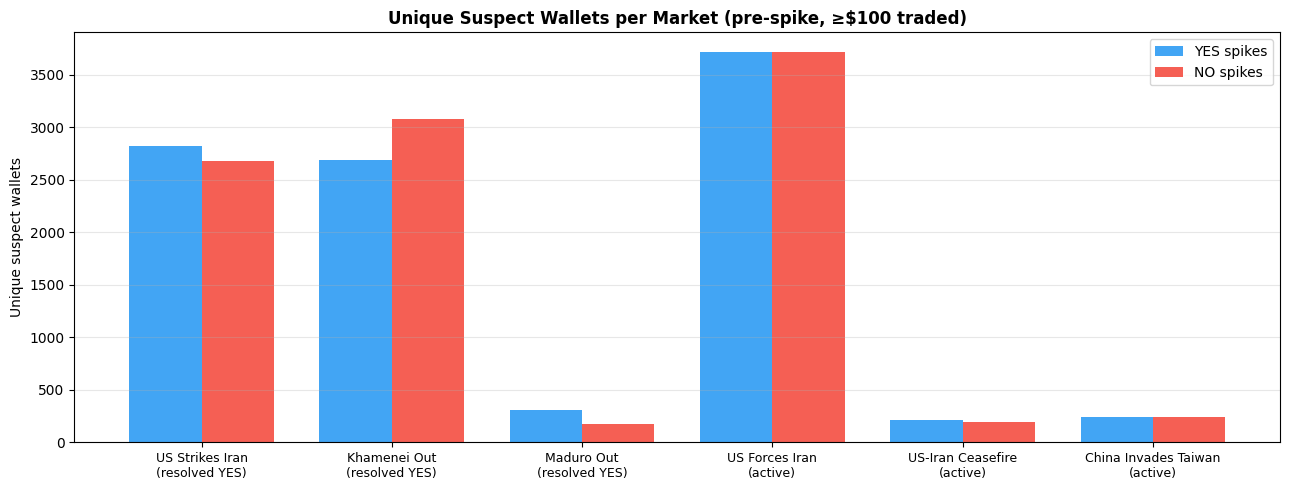

Saved: trace_charts/suspects_per_market.png


In [14]:
market_labels = {
    "us-strikes-iran-feb28":     "US Strikes Iran\n(resolved YES)",
    "khamenei-out-feb28":        "Khamenei Out\n(resolved YES)",
    "maduro-out-jan31":          "Maduro Out\n(resolved YES)",
    "us-forces-iran-mar31":      "US Forces Iran\n(active)",
    "us-iran-ceasefire-jun30":   "US-Iran Ceasefire\n(active)",
    "china-invades-taiwan-2026": "China Invades Taiwan\n(active)",
}
market_order = list(market_labels.keys())

per_market_pd = (
    suspects
    .groupBy("market_slug", "spike_side")
    .agg(F.countDistinct("wallet_address").alias("unique_wallets"))
    .toPandas()
)

# pivot to yes/no columns
pivot = per_market_pd.pivot(index="market_slug", columns="spike_side", values="unique_wallets").fillna(0)
pivot = pivot.reindex([m for m in market_order if m in pivot.index])

x = np.arange(len(pivot))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 5))
if "yes" in pivot.columns:
    ax.bar(x - width / 2, pivot["yes"], width, label="YES spikes", color="#2196F3", alpha=0.85)
if "no" in pivot.columns:
    ax.bar(x + width / 2, pivot["no"], width, label="NO spikes", color="#F44336", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([market_labels.get(m, m) for m in pivot.index], fontsize=9)
ax.set_ylabel("Unique suspect wallets")
ax.set_title("Unique Suspect Wallets per Market (pre-spike, ≥$100 traded)", fontsize=12, fontweight="bold")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(CHART_DIR / "suspects_per_market.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: trace_charts/suspects_per_market.png")

> **Chart interpretation — Unique Suspect Wallets per Market:**
>
> Blue bars = wallets that were buying YES before YES spikes. Red bars = wallets buying NO before NO spikes.
>
> Markets with many YES suspects and few NO suspects show clear directional bias — many wallets were consistently betting on the event happening. Markets with roughly equal YES and NO suspects are noisier, with wallets betting in both directions around different spikes.
>
> Note that a high unique wallet count can also just reflect a large, active market. The resolved markets (left three) are more meaningful here because we know which side was correct — any wallet in those YES bars ultimately made money.

### 8.2 Top Wallets for Each Resolved Market's Resolution Spike

For each of the 3 resolved markets, show the top 10 wallets by total USD traded in the 24 hours before the resolution spike. Color encodes how early they started (blue = very early, red = close to the spike).

26/05/03 08:22:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:53 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


26/05/03 08:22:54 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:54 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:54 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:22:54 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


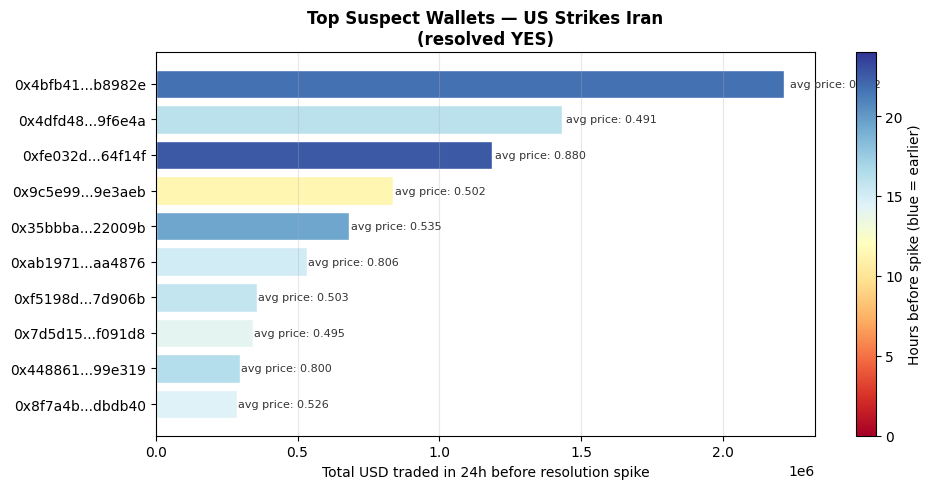

Saved: trace_charts/top_wallets_us-strikes-iran-feb28.png


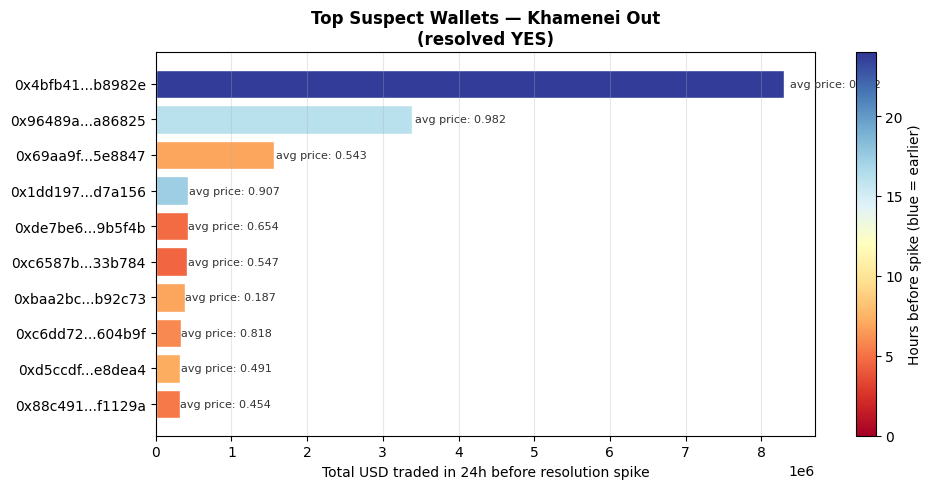

Saved: trace_charts/top_wallets_khamenei-out-feb28.png


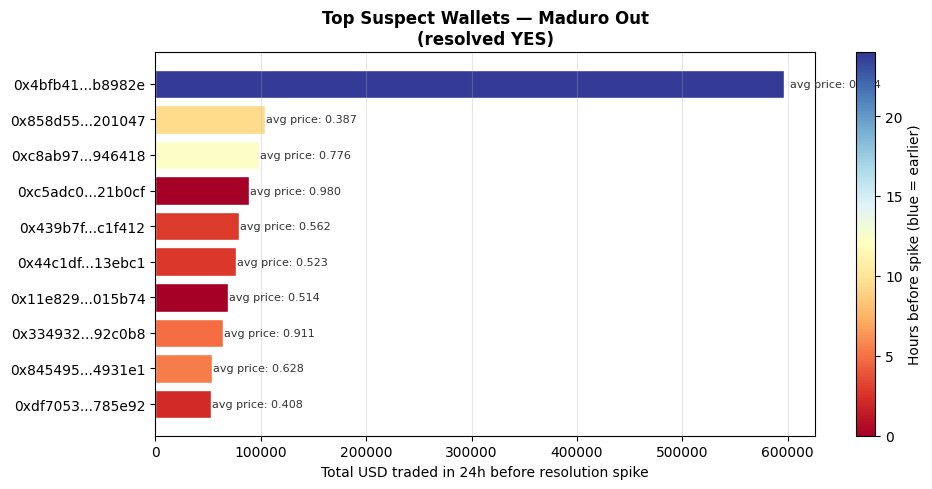

Saved: trace_charts/top_wallets_maduro-out-jan31.png


In [15]:
suspects_pd = suspects.toPandas()
suspects_pd["spike_timestamp"] = pd.to_datetime(suspects_pd["spike_timestamp"]).dt.tz_localize(None)

cmap = plt.cm.RdYlBu

for slug, (date, side) in resolution_spikes.items():
    res_day = pd.Timestamp(date)
    mdf = suspects_pd[
        (suspects_pd["market_slug"] == slug) &
        (suspects_pd["spike_side"] == side) &
        (suspects_pd["spike_timestamp"].dt.date == res_day.date())
    ]

    if mdf.empty:
        print(f"No suspects found for {slug} on {date}")
        continue

    # aggregate across all resolution-day spikes for this market
    top = (
        mdf.groupby("wallet_address", as_index=False)
        .agg(
            total_usd=("total_usd", "sum"),
            fill_count=("fill_count", "sum"),
            avg_price=("avg_price", "mean"),
            avg_hours=("hours_before_spike", "mean"),
        )
        .sort_values("total_usd", ascending=False)
        .head(10)
    )

    # shorten wallet addresses for readability
    top["wallet_short"] = top["wallet_address"].apply(lambda w: w[:8] + "..." + w[-6:])

    # color by how early they bet (high hours_before = blue = early = more suspicious)
    norm = mcolors.Normalize(vmin=0, vmax=LOOKBACK_HOURS)
    colors = [cmap(norm(h)) for h in top["avg_hours"]]

    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.barh(top["wallet_short"][::-1], top["total_usd"][::-1], color=colors[::-1], edgecolor="white")

    # annotate bars with avg_price
    for bar, price in zip(bars, top["avg_price"][::-1]):
        ax.text(
            bar.get_width() + bar.get_width() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"avg price: {price:.3f}",
            va="center", fontsize=8, color="#333333",
        )

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label="Hours before spike (blue = earlier)")

    ax.set_xlabel("Total USD traded in 24h before resolution spike")
    ax.set_title(f"Top Suspect Wallets — {market_labels[slug]}", fontsize=12, fontweight="bold")
    ax.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()

    fname = f"top_wallets_{slug}.png"
    plt.savefig(CHART_DIR / fname, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: trace_charts/{fname}")

> **Chart interpretation — Top Suspect Wallets (per resolved market):**
>
> Each bar is one wallet. Bar length = total USD they traded in the 24 hours before the resolution spike. Color = how early they started — blue means they were buying many hours before the spike (suspicious), red means they jumped in right before (possibly just reacting to news).
>
> The `avg price` annotation on each bar is key. For the YES side:
> - **Low avg price + blue color** = bought YES when it was cheap and early = strongest insider signal
> - **High avg price + red color** = bought when YES was already expensive and close to the spike = likely a late news reactor
>
> Wallets that appear across multiple resolved markets (both Feb 28 charts, or both Feb 28 and Maduro) would be an even stronger signal. Phase 5 will cross-reference across all markets to find those.

### 8.3 Distribution of Hours Before Spike

Across all suspects and all markets, when did wallets start trading relative to the spike they preceded? The shape of this distribution tells us whether suspect activity tends to be close to spikes (reactive) or spread across the full 24-hour window (anticipatory).

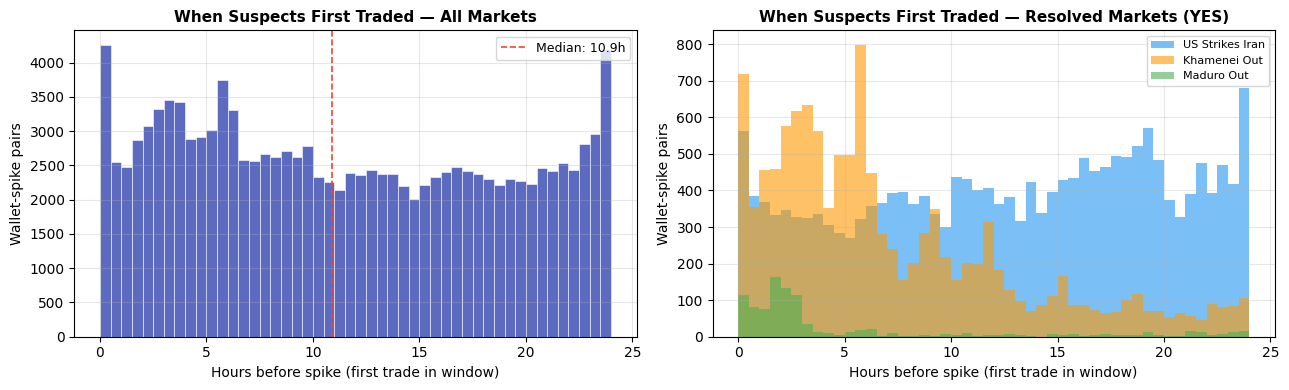

Saved: trace_charts/hours_before_spike.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: overall distribution
ax = axes[0]
ax.hist(
    suspects_pd["hours_before_spike"].clip(0, LOOKBACK_HOURS),
    bins=48,
    range=(0, LOOKBACK_HOURS),
    color="#5C6BC0",
    edgecolor="white",
    linewidth=0.4,
)
ax.set_xlabel("Hours before spike (first trade in window)")
ax.set_ylabel("Wallet-spike pairs")
ax.set_title("When Suspects First Traded — All Markets", fontsize=11, fontweight="bold")
ax.axvline(x=suspects_pd["hours_before_spike"].median(), color="#F44336", linestyle="--",
           linewidth=1.2, label=f"Median: {suspects_pd['hours_before_spike'].median():.1f}h")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: resolved markets only (YES side), 30-min bins
ax = axes[1]
for slug, color, label in [
    ("us-strikes-iran-feb28", "#2196F3", "US Strikes Iran"),
    ("khamenei-out-feb28",    "#FF9800", "Khamenei Out"),
    ("maduro-out-jan31",      "#4CAF50", "Maduro Out"),
]:
    mdf = suspects_pd[
        (suspects_pd["market_slug"] == slug) &
        (suspects_pd["spike_side"] == "yes")
    ]
    ax.hist(
        mdf["hours_before_spike"].clip(0, LOOKBACK_HOURS),
        bins=48, range=(0, LOOKBACK_HOURS),
        alpha=0.6, color=color, label=label,
    )
ax.set_xlabel("Hours before spike (first trade in window)")
ax.set_ylabel("Wallet-spike pairs")
ax.set_title("When Suspects First Traded — Resolved Markets (YES)", fontsize=11, fontweight="bold")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(CHART_DIR / "hours_before_spike.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: trace_charts/hours_before_spike.png")

> **Chart interpretation — Distribution of Hours Before Spike:**
>
> **Left chart (all markets):** Each count is one wallet-spike pair. The x-axis is hours before the spike, so 0 = just before the spike and 24 = a full day before.
>
> If trading were random with respect to the spike, we would expect a roughly flat distribution — equal activity at all points in the 24-hour window. A spike near 0 means suspects cluster right before events (reactive); a spike near 24 or a bimodal distribution would suggest some suspects start very early (anticipatory).
>
> The red dashed median line shows the typical timing for first trade in a window.
>
> **Right chart (resolved markets, YES side):** Breaking out the three resolved markets shows whether their suspect timing patterns differ. Maduro was thin so its counts are lower. US Strikes Iran and Khamenei had much more pre-spike activity. Any peak toward the left (high hours) in this chart is evidence of buying well in advance of the event.

---

## 9. Write `suspect_wallets` to BigQuery

In [17]:
t0 = time.time()
write_bq(suspects, "suspect_wallets")
print(f"suspect_wallets written ({time.time() - t0:.1f}s)")
print(f"Rows: {suspect_count:,}")

26/05/03 08:24:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:24:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:24:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:24:29 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


26/05/03 08:24:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:24:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:24:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/05/03 08:24:30 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


suspect_wallets written (119.4s)
Rows: 128,096


> **What this output means:**
>
> The `suspect_wallets` table is now persisted in BigQuery. Phase 5 will read this table and cross-reference each wallet's trades against GDELT news timestamps to compute a `prescience_score` — how often did a wallet bet correctly *before* the relevant news became public?
>
> Schema written:
> - `spike_id` / `market_slug` / `spike_side` / `spike_timestamp` — which spike this entry is for
> - `wallet_address` / `role` — who (taker = bought correct side; maker = sold opposite side)
> - `total_usd` / `fill_count` / `avg_price` — their position size and entry price
> - `first_bet_timestamp` / `hours_before_spike` — timing relative to the spike

---

## 10. Summary

In [18]:
print("=" * 52)
print("Phase 4 — Bet Tracing Summary")
print("=" * 52)
print(f"Spike events traced         : {spike_count}")
print(f"Look-back window            : {LOOKBACK_HOURS} hours")
print(f"Min wallet threshold        : ${MIN_WALLET_USD:,.0f}")
print(f"Taker match rows            : {taker_count:,}")
print(f"Maker match rows            : {maker_count:,}")
print(f"Wallet-spike pairs (raw)    : {raw_count:,}")
print(f"Suspect entries (filtered)  : {suspect_count:,}")
print(f"Distinct suspect wallets    : {distinct_wallets:,}")
print(f"Spark master                : {spark.sparkContext.master}")
print("\nBigQuery table written:")
print("  polymarket.suspect_wallets")
print("\nCharts saved to: trace_charts/")
print("  suspects_per_market.png")
print("  top_wallets_us-strikes-iran-feb28.png")
print("  top_wallets_khamenei-out-feb28.png")
print("  top_wallets_maduro-out-jan31.png")
print("  hours_before_spike.png")

Phase 4 — Bet Tracing Summary
Spike events traced         : 569
Look-back window            : 24 hours
Min wallet threshold        : $100
Taker match rows            : 720,622
Maker match rows            : 711,314
Wallet-spike pairs (raw)    : 389,278
Suspect entries (filtered)  : 128,096
Distinct suspect wallets    : 13,068
Spark master                : local[*]

BigQuery table written:
  polymarket.suspect_wallets

Charts saved to: trace_charts/
  suspects_per_market.png
  top_wallets_us-strikes-iran-feb28.png
  top_wallets_khamenei-out-feb28.png
  top_wallets_maduro-out-jan31.png
  hours_before_spike.png


---

## 11. Stop Spark

In [19]:
spark.stop()
print("Spark stopped")

Spark stopped
